# EDA

Импорты и пути

In [21]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.io import loadmat
from PIL import Image

PROJECT_DIR = Path.cwd().parent
RAW_DIR = PROJECT_DIR / "data" / "raw"

VEHICLE_DIR = RAW_DIR / "Udacity Self Driving Car Dataset"

Общий обзор данных 

In [22]:
def count_files(path):
    return sum(1 for _ in path.rglob("*") if _.is_file())

print("Vehicle dataset total files:", count_files(VEHICLE_DIR))

Vehicle dataset total files: 29802


## Udacity Self Driving Car Dataset

### Структура данных (после download -> organize)

In [23]:
for item in VEHICLE_DIR.iterdir():
    print(item.name)

images
labels
README.roboflow.txt


### Проверка данных

In [24]:
images_dir_ud = VEHICLE_DIR / "images"
labels_dir_ud = VEHICLE_DIR / "labels"

print("Images:", len(list(images_dir_ud.glob("*"))))
print("Labels:", len(list(labels_dir_ud.glob("*"))))

Images: 29800
Labels: 1


### Форматы аннотаций

In [25]:
extensions = set(p.suffix for p in labels_dir_ud.glob("*"))
print("Label file types:", extensions)

Label file types: {'.csv'}


### Просмотр примеров label-файлов

In [26]:
sample_label_files = list(labels_dir_ud.glob("*"))[:5]

for p in sample_label_files:
    print("=" * 80)
    print(p.name)
    print(p.suffix.lower())
    try:
        with open(p, "r", encoding="utf-8", errors="ignore") as f:
            print(f.read(500))
    except Exception as e:
        print("Cannot read file:", e)

_annotations.csv
.csv
filename,width,height,class,xmin,ymin,xmax,ymax
1478900859981702684_jpg.rf.6830635c7d9197475638f0818f5dd103.jpg,512,512,car,291,247,370,331
1478900859981702684_jpg.rf.6830635c7d9197475638f0818f5dd103.jpg,512,512,pedestrian,270,235,293,321
1478900859981702684_jpg.rf.6830635c7d9197475638f0818f5dd103.jpg,512,512,car,0,266,13,327
1478900859981702684_jpg.rf.6830635c7d9197475638f0818f5dd103.jpg,512,512,car,25,258,106,304
1478900859981702684_jpg.rf.6830635c7d9197475638f0818f5dd103.jpg,512,512,car,111,2


### Проверка структуры image <-> annotations

In [27]:
image_names = {p.stem for p in images_dir_ud.glob("*")}
label_names = {p.stem for p in labels_dir_ud.glob("*")}

print("Images:", len(image_names))
print("Labels:", len(label_names))
print("Matched:", len(image_names & label_names))

Images: 29800
Labels: 1
Matched: 0


### Анализ CSV-аннотаций

In [28]:
csv_files = list(labels_dir_ud.glob("*.csv"))
print("CSV files:", [p.name for p in csv_files])

df_ann = pd.read_csv(csv_files[0])
print(df_ann.shape)
df_ann.head()

CSV files: ['_annotations.csv']
(194539, 8)


,filename,width,height,class,xmin,ymin,xmax,ymax
0,1478900859981702684_jpg.rf.6830635c7d919747563...,512,512,car,291,247,370,331
1,1478900859981702684_jpg.rf.6830635c7d919747563...,512,512,pedestrian,270,235,293,321
2,1478900859981702684_jpg.rf.6830635c7d919747563...,512,512,car,0,266,13,327
3,1478900859981702684_jpg.rf.6830635c7d919747563...,512,512,car,25,258,106,304
4,1478900859981702684_jpg.rf.6830635c7d919747563...,512,512,car,111,259,135,289


In [29]:
print(df_ann.columns.tolist())
print(df_ann["class"].value_counts())

['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']
class
car                        127873
pedestrian                  21491
trafficLight-Red            13673
trafficLight-Green          10838
truck                        7194
trafficLight                 5101
biker                        3704
trafficLight-RedLeft         3482
trafficLight-GreenLeft        614
trafficLight-Yellow           541
trafficLight-YellowLeft        28
Name: count, dtype: int64


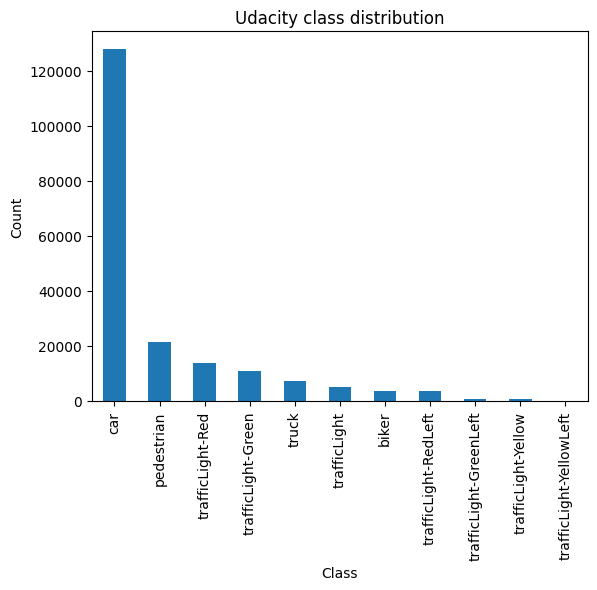

In [30]:
df_ann["class"].value_counts().plot(kind="bar")
plt.title("Udacity class distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [31]:
print("Unique images in annotations:", df_ann["filename"].nunique())
print("Total annotation rows:", len(df_ann))

Unique images in annotations: 26300
Total annotation rows: 194539


In [32]:
bbox_width = df_ann["xmax"] - df_ann["xmin"]
bbox_height = df_ann["ymax"] - df_ann["ymin"]
bbox_area = bbox_width * bbox_height

bbox_df = pd.DataFrame({
    "bbox_width": bbox_width,
    "bbox_height": bbox_height,
    "bbox_area": bbox_area,
})

bbox_df.describe()

,bbox_width,bbox_height,bbox_area
count,194539.000000,194539.000000,194539.000000
mean,35.457800,52.215453,3249.297354
std,37.116167,48.687664,8312.218968
min,1.000000,3.000000,4.000000
25%,13.000000,26.000000,368.000000
50%,23.000000,36.000000,810.000000
75%,43.000000,58.000000,2257.000000
max,457.000000,511.000000,134976.000000


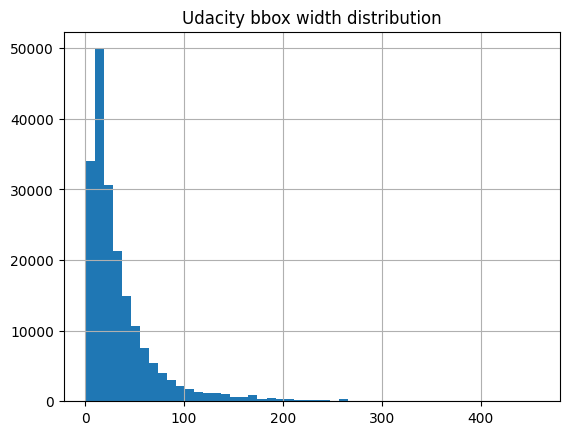

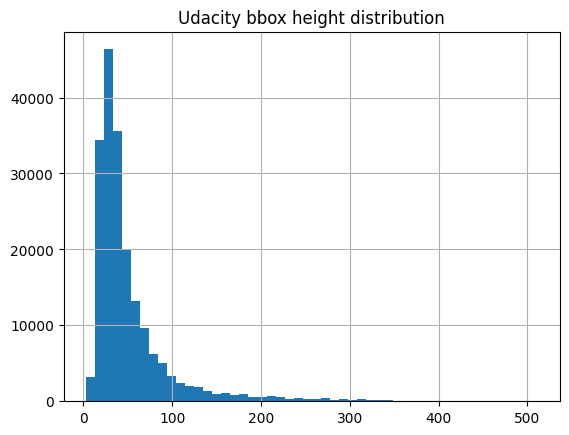

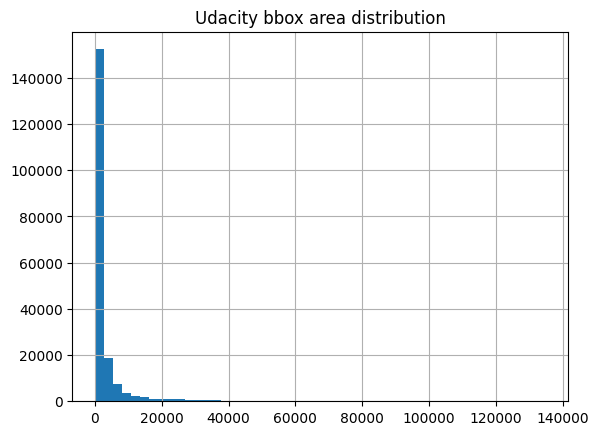

In [33]:
bbox_df["bbox_width"].hist(bins=50)
plt.title("Udacity bbox width distribution")
plt.show()

bbox_df["bbox_height"].hist(bins=50)
plt.title("Udacity bbox height distribution")
plt.show()

bbox_df["bbox_area"].hist(bins=50)
plt.title("Udacity bbox area distribution")
plt.show()

### Проверка дубликатов имён (после organize)

In [34]:
image_files_ud = list(images_dir_ud.glob("*"))
image_names_ud = [p.name for p in image_files_ud]

print("Total image files:", len(image_names_ud))
print("Unique image filenames:", len(set(image_names_ud)))

Total image files: 29800
Unique image filenames: 29800


In [35]:
label_names_full = [p.name for p in list(labels_dir_ud.glob("*"))]

print("Total label files:", len(label_names_full))
print("Unique label filenames:", len(set(label_names_full)))

Total label files: 1
Unique label filenames: 1


### Проверка битых изображений

In [36]:
broken_ud_images = []

for img_path in image_files_ud[:1000]:
    try:
        img = Image.open(img_path)
        img.verify()
    except Exception:
        broken_ud_images.append(img_path.name)

print("Broken Udacity images:", len(broken_ud_images))

Broken Udacity images: 0


### Размеры изображений

In [37]:
ud_sizes = []

for img_path in image_files_ud[:500]:
    img = Image.open(img_path)
    ud_sizes.append(img.size)

ud_sizes_df = pd.DataFrame(ud_sizes, columns=["width", "height"])
ud_sizes_df.describe()

,width,height
count,500.0,500.0
mean,512.0,512.0
std,0.0,0.0
min,512.0,512.0
25%,512.0,512.0
50%,512.0,512.0
75%,512.0,512.0
max,512.0,512.0


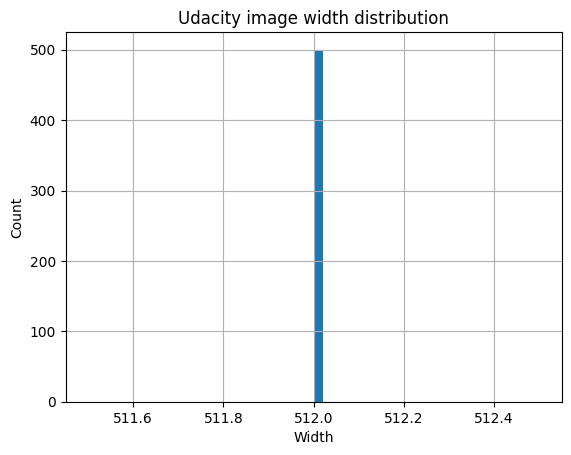

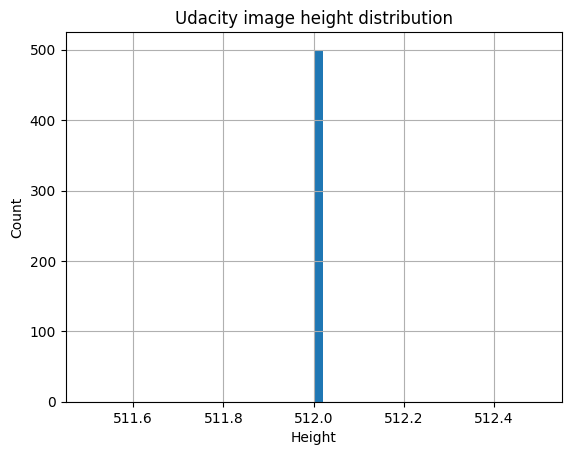

In [38]:
ud_sizes_df["width"].hist(bins=50)
plt.title("Udacity image width distribution")
plt.xlabel("Width")
plt.ylabel("Count")
plt.show()

ud_sizes_df["height"].hist(bins=50)
plt.title("Udacity image height distribution")
plt.xlabel("Height")
plt.ylabel("Count")
plt.show()

### Визуальный просмотр изображений Udacity

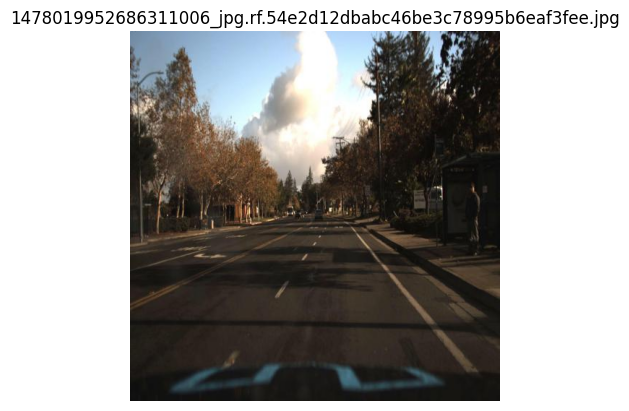

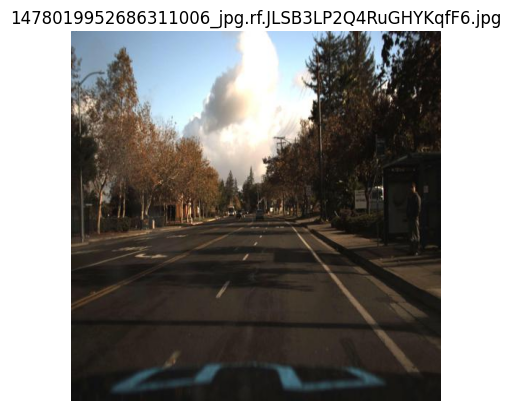

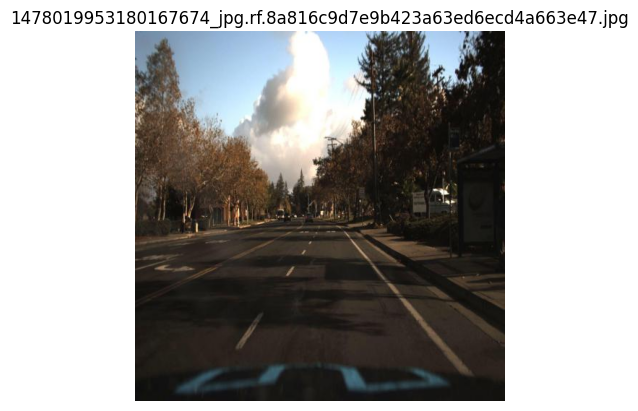

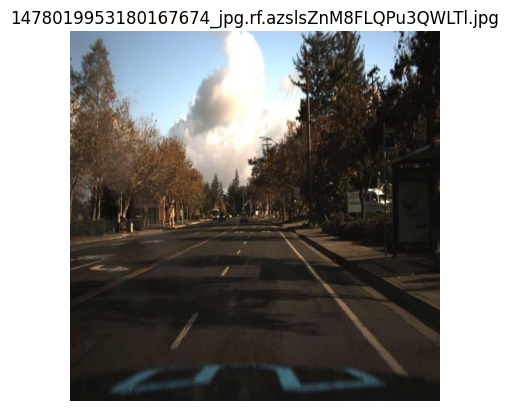

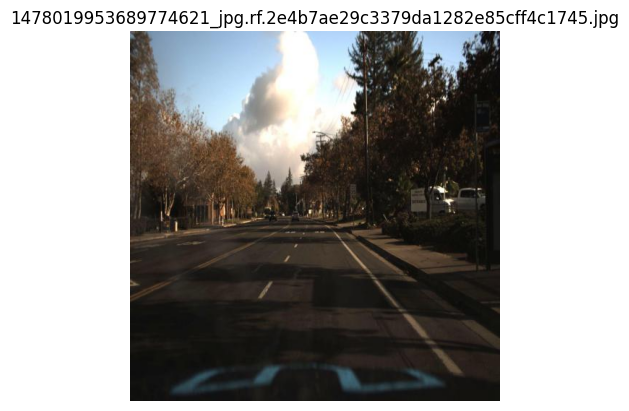

In [39]:
sample_ud_images = image_files_ud[:5]

for img_path in sample_ud_images:
    img = Image.open(img_path).convert("RGB")
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

## Выводы

### Общая оценка данных

Проведённый анализ показал, что используемый датасет Udacity Self Driving Car Dataset пригоден для решения задачи детекции транспортных средств.

Данные успешно загружены и организованы в единую структуру, при этом:
- отсутствуют повреждённые изображения;
- изображения и аннотации доступны после этапа `organize`;
- структура каталога согласована с дальнейшим пайплайном обработки.

### Udacity Self Driving Car Dataset (детекция)

Датасет ориентирован на задачу детекции объектов и содержит аннотации в формате bounding boxes.

Ключевые особенности:
- аннотации централизованы в CSV-файле;
- одно изображение может содержать несколько объектов;
- изображения имеют фиксированный размер, что упрощает preprocessing;
- структура данных соответствует задаче object detection.

### Вывод для дальнейшего пайплайна

На основе проведённого анализа можно заключить, что для корректной работы системы необходимо реализовать этап `processing`, который:
- приведёт данные к единому формату;
- преобразует CSV-аннотации в удобную для обучения структуру;
- обеспечит воспроизводимость подготовки данных;
- подготовит данные для обучения и инференса модели детекции.

### Итог

EDA подтвердил, что данные являются качественными и пригодными для построения detection-only пайплайна.

Основные задачи следующего этапа:
- выбор лучшей detection-модели;
- перенос обработки данных и модели в модульную структуру проекта;
- последующая интеграция в сервис и финальный pipeline.